In [121]:
# Vectorisation photo raster → DXF
# Flow : grayscale → segmentation fond → contours → simplification → DXF

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ezdxf
from pathlib import Path

In [122]:
def _sample_border_grayscale(gray: np.ndarray, margin_ratio: float = 0.08) -> np.ndarray:
    """Échantillonne les pixels sur une bande en bordure de l'image (supposée être le fond)."""
    h, w = gray.shape
    m = max(1, int(min(h, w) * margin_ratio))
    top = gray[:m, :].ravel()
    bottom = gray[-m:, :].ravel()
    left = gray[:, :m].ravel()
    right = gray[:, -m:].ravel()
    return np.concatenate([top, bottom, left, right])


def _segment_by_background(gray: np.ndarray, background_tolerance: float = 25.0) -> np.ndarray:
    """
    Estime le fond depuis les bords (médiane), puis segmente : tout pixel à moins de
    background_tolerance sous cette valeur est considéré comme fond (0), le reste forme (255).
    background_tolerance en 0-255 ; plus élevé = plus de pixels retirés comme fond.
    """
    samples = _sample_border_grayscale(gray)
    if len(samples) == 0:
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary
    bg_value = float(np.median(samples))
    thresh = max(0, min(255, bg_value - background_tolerance))
    _, binary = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    return binary


def _segment_otsu(gray: np.ndarray) -> np.ndarray:
    """Binarisation par méthode d'Otsu (seuil optimal automatique, pas de paramètre)."""
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary


def load_grayscale_threshold(
    image_path: str,
    method: str = "background",
    background_tolerance: float = 25.0,
) -> np.ndarray:
    """
    Charge l'image, grayscale, puis segmente fond/forme.
    method: "background" = estimation du fond par les bords + tolerance ;
            "otsu" = seuil automatique d'Otsu.
    background_tolerance (si method=background): écart sous la couleur de fond estimée (0-255).
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image non trouvée: {image_path}")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if method == "otsu":
        return _segment_otsu(gray)
    return _segment_by_background(gray, background_tolerance)


def load_steps(
    image_path: str,
    method: str = "background",
    background_tolerance: float = 25.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Retourne (original RGB, grayscale, binaire) pour visualisation.
    method: "background" ou "otsu". background_tolerance utilisé si method="background".
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image non trouvée: {image_path}")
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if method == "otsu":
        binary = _segment_otsu(gray)
    else:
        binary = _segment_by_background(gray, background_tolerance)
    return rgb, gray, binary

In [123]:
def contours_to_svg_paths(contours: list, epsilon_factor: float = 0.002) -> list[str]:
    """
    Simplifie les contours avec Douglas-Peucker (approxPolyDP) et retourne une liste de
    chaînes SVG path 'd'. epsilon_factor contrôle l'agressivité (plus grand = moins de points).
    """
    paths = []
    for cnt in contours:
        if len(cnt) < 3:
            continue
        perimeter = cv2.arcLength(cnt, True)
        epsilon = max(1.0, perimeter * epsilon_factor)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) < 2:
            continue
        pts = approx.reshape(-1, 2)
        d = f"M {pts[0, 0]:.1f} {pts[0, 1]:.1f}"
        for i in range(1, len(pts)):
            d += f" L {pts[i, 0]:.1f} {pts[i, 1]:.1f}"
        d += " Z"
        paths.append(d)
    return paths


def get_simplified_contours(contours: list, epsilon_factor: float = 0.002) -> list[np.ndarray]:
    """Retourne les contours simplifiés (pour dessin) sans les convertir en chaînes SVG."""
    simplified = []
    for cnt in contours:
        if len(cnt) < 3:
            continue
        perimeter = cv2.arcLength(cnt, True)
        epsilon = max(1.0, perimeter * epsilon_factor)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) >= 2:
            simplified.append(approx)
    return simplified

In [124]:
def write_dxf(contours: list, width: int, height: int, out_path: str) -> None:
    """
    Écrit un fichier DXF avec des LWPOLYLINE fermées. Passe de l'origine image (Y vers le bas)
    en coordonnées DXF (Y vers le haut) : dxf_y = height - y.
    """
    doc = ezdxf.new("R2010")
    msp = doc.modelspace()
    for cnt in contours:
        if len(cnt) < 2:
            continue
        pts = cnt.reshape(-1, 2)
        pts_dxf = [(float(x), height - float(y)) for x, y in pts]
        msp.add_lwpolyline(pts_dxf, close=True)
    doc.saveas(out_path)

In [125]:
def write_svg(paths: list[str], width: int, height: int, out_path: str) -> None:
    """Écrit un fichier SVG avec les paths fournis, viewBox selon width/height."""
    path_elements = "\n  ".join(f'<path d="{p}" fill="black" stroke="none"/>' for p in paths)
    svg = f'''<?xml version="1.0" encoding="UTF-8"?>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}" width="{width}" height="{height}">
  {path_elements}
</svg>'''
    Path(out_path).write_text(svg, encoding="utf-8")

In [126]:
def raster_to_dxf(
    image_path: str,
    output_dxf_path: str,
    method: str = "background",
    background_tolerance: float = 25.0,
    epsilon_factor: float = 0.002,
    min_contour_area: int = 50,
) -> tuple[np.ndarray, int]:
    """
    Pipeline complet : chargement → grayscale → segmentation fond → contours → simplification → DXF.
    method: "background" (estimation par les bords) ou "otsu".
    Retourne (image binaire, nombre total de points dans le DXF).
    """
    binary = load_grayscale_threshold(image_path, method=method, background_tolerance=background_tolerance)
    h, w = binary.shape
    contours, _ = cv2.findContours(255 - binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) >= min_contour_area]
    contours_simplified = get_simplified_contours(contours, epsilon_factor)
    write_dxf(contours_simplified, w, h, output_dxf_path)
    total_points = sum(len(c) for c in contours_simplified)
    return binary, total_points

In [127]:
# Exemple d'utilisation : adapter les chemins et paramètres
IMAGE_PATH = r"C:\Users\mvm\open3d_vision\data\test_4.jpg"
OUTPUT_DXF = r"C:\Users\mvm\open3d_vision\data\test_4.dxf"

# method: "background" (estimation par les bords) ou "otsu" (seuil auto)
# background_tolerance: si method=background, écart sous le fond estimé (ex. 20-50)
binary_img, num_points = raster_to_dxf(
    IMAGE_PATH,
    OUTPUT_DXF,
    method="background",
    background_tolerance=25.0,
    epsilon_factor=0.005,
    min_contour_area=50,
)
print(f"DXF écrit : {OUTPUT_DXF} — environ {num_points} points")

DXF écrit : C:\Users\mvm\open3d_vision\data\test_4.dxf — environ 5640 points


In [128]:
def plot_pipeline_steps(
    image_path: str,
    method: str = "background",
    background_tolerance: float = 25.0,
    epsilon_factor: float = 0.005,
    min_contour_area: int = 50,
    figsize: tuple[int, int] = (14, 10),
) -> None:
    """
    Affiche les transformations étape par étape. method: "background" ou "otsu".
    background_tolerance (method=background): écart sous le fond estimé (0-255).
    """
    rgb, gray, binary = load_steps(image_path, method=method, background_tolerance=background_tolerance)
    contours, _ = cv2.findContours(255 - binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_filtered = [c for c in contours if cv2.contourArea(c) >= min_contour_area]
    contours_simplified = get_simplified_contours(contours_filtered, epsilon_factor)

    img_contours = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_contours, contours_filtered, -1, (0, 180, 0), 2)

    img_simplified = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_simplified, contours_simplified, -1, (200, 0, 0), 2)

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("1. Original (RGB)")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(gray, cmap="gray")
    axes[0, 1].set_title("2. Grayscale")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(binary, cmap="gray")
    axes[0, 2].set_title("3. Binaire (segmentation fond)")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title(f"4. Contours bruts ({len(contours_filtered)} formes)")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(cv2.cvtColor(img_simplified, cv2.COLOR_BGR2RGB))
    n_pts = sum(len(c) for c in contours_simplified)
    axes[1, 1].set_title(f"5. Contours simplifiés (~{n_pts} points)")
    axes[1, 1].axis("off")

    # Récap texte
    axes[1, 2].axis("off")
    axes[1, 2].text(
        0.1, 0.8, "Récapitulatif", fontsize=12, fontweight="bold"
    )
    axes[1, 2].text(
        0.1, 0.5,
        f"method: {method}\n"
        f"background_tolerance: {background_tolerance}\n"
        f"epsilon_factor: {epsilon_factor}\n"
        f"Contours retenus: {len(contours_filtered)}\n"
        f"Points après simplification: ~{n_pts}",
        fontsize=10, verticalalignment="center", family="monospace"
    )

    plt.tight_layout()
    plt.show()

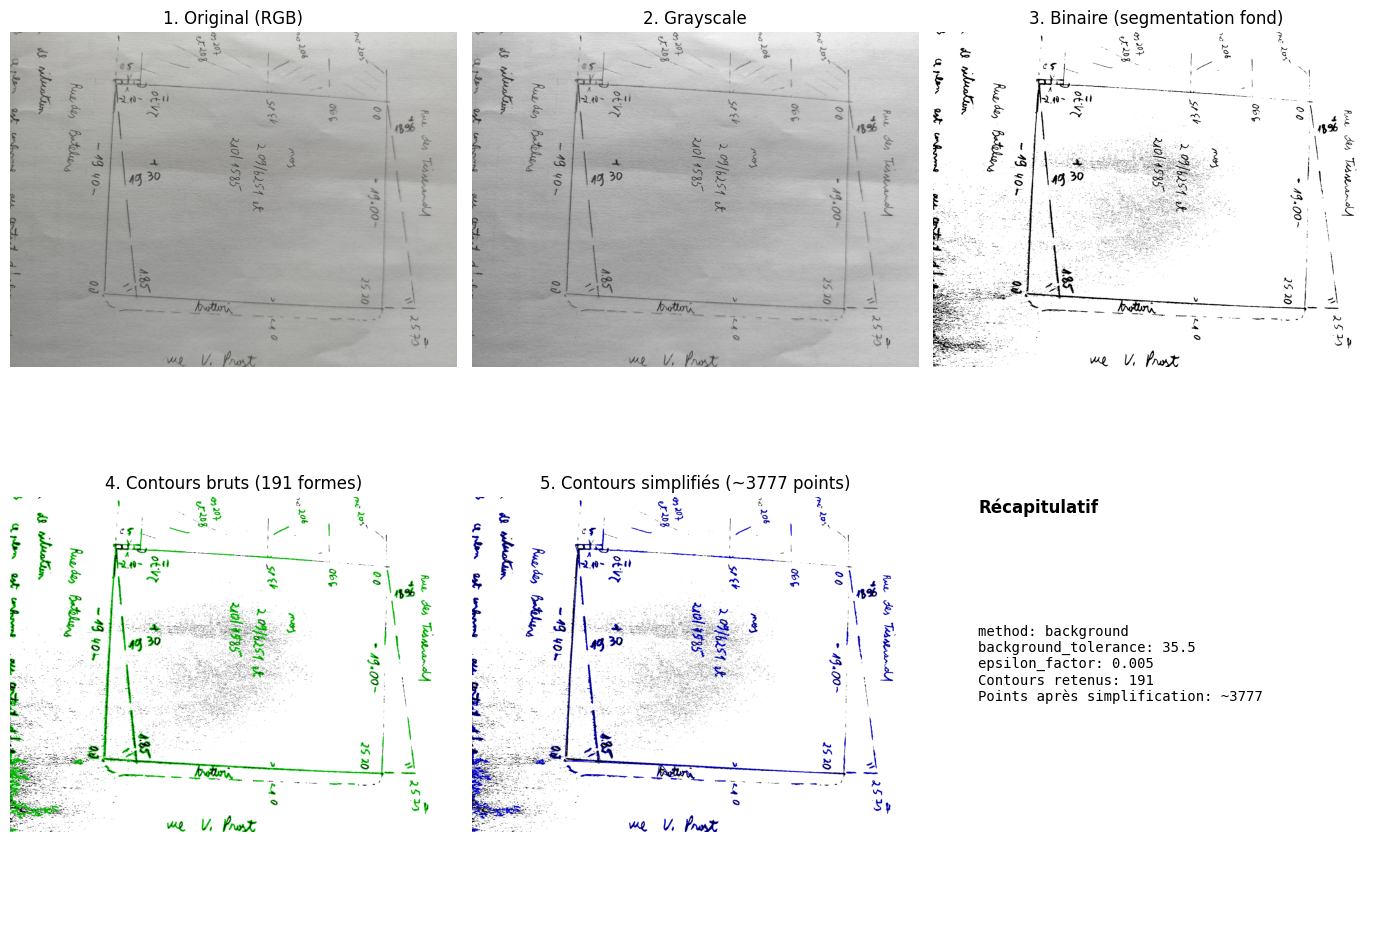

In [129]:
# Visualisation des étapes
# method="otsu" si "background" ne convient pas (seuil automatique)
plot_pipeline_steps(
    IMAGE_PATH,
    method="background",
    background_tolerance=35.5,
    epsilon_factor=0.005,
    min_contour_area=50,
)